In [4]:
# ================================
# IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
from zipfile import ZipFile
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [5]:
# ================================
# DOWNLOAD MOVIELENS DATASET
# ================================
movielens_data_file_url = (
    "http://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
)

movielens_zipped_file = keras.utils.get_file(
    "ml-latest-small.zip",
    movielens_data_file_url,
    extract=False
)

keras_datasets_path = Path(movielens_zipped_file).parents[0]
movielens_dir = keras_datasets_path / "ml-latest-small"

# Extract only once
if not movielens_dir.exists():
    with ZipFile(movielens_zipped_file, "r") as zip:
        print("Extracting files...")
        zip.extractall(path=keras_datasets_path)
        print("Done!")

# ================================
# LOAD CSV FILES
# ================================
ratings_file = movielens_dir / "ratings.csv"
movies_file = movielens_dir / "movies.csv"
tags_file = movielens_dir / "tags.csv"

df = pd.read_csv(ratings_file)
movies = pd.read_csv(movies_file)
tags = pd.read_csv(tags_file)

978202/978202 ━━━━━━━━━━━━━━━━━━━━ 5s 5us/step
Extracting files...
Done!


In [6]:
df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [7]:
df.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [9]:
# ================================
# ENCODE USERS & MOVIES
# ================================
user_ids = df["userId"].unique().tolist()
movie_ids = df["movieId"].unique().tolist()

user2user_encoded = {x: i for i, x in enumerate(user_ids)}
user_encoded2user = {i: x for i, x in enumerate(user_ids)}

movie2movie_encoded = {x: i for i, x in enumerate(movie_ids)}
movie_encoded2movie = {i: x for i, x in enumerate(movie_ids)}

df["user"] = df["userId"].map(user2user_encoded)
df["movie"] = df["movieId"].map(movie2movie_encoded)

num_users = len(user2user_encoded)
num_movies = len(movie2movie_encoded)

# ================================
# NORMALIZE RATINGS
# ================================
df["rating"] = df["rating"].values.astype(np.float32)

min_rating = df["rating"].min()
max_rating = df["rating"].max()

print("Number of users:", num_users)
print("Number of movies:", num_movies)
print("Min rating:", min_rating, "Max rating:", max_rating)

# Shuffle dataset
df = df.sample(frac=1, random_state=42)

X = df[["user", "movie"]].values
y = df["rating"].apply(
    lambda x: (x - min_rating) / (max_rating - min_rating)
).values

Number of users: 610
Number of movies: 9724
Min rating: 0.5 Max rating: 5.0


In [10]:
# ================================
# TRAIN-TEST SPLIT
# ================================
train_indices = int(0.9 * df.shape[0])

x_train, x_val = X[:train_indices], X[train_indices:]
y_train, y_val = y[:train_indices], y[train_indices:]

In [11]:
# ================================
# MODEL DEFINITION
# ================================
EMBEDDING_SIZE = 50

class RecommenderNet(keras.Model):
    def __init__(self, num_users, num_movies, embedding_size, **kwargs):
        super(RecommenderNet, self).__init__(**kwargs)

        self.user_embedding = layers.Embedding(
            num_users,
            embedding_size,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6),
        )
        self.user_bias = layers.Embedding(num_users, 1)

        self.movie_embedding = layers.Embedding(
            num_movies,
            embedding_size,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6),
        )
        self.movie_bias = layers.Embedding(num_movies, 1)

    def call(self, inputs):
        user_vector = self.user_embedding(inputs[:, 0])
        user_bias = self.user_bias(inputs[:, 0])

        movie_vector = self.movie_embedding(inputs[:, 1])
        movie_bias = self.movie_bias(inputs[:, 1])

        dot_user_movie = tf.reduce_sum(user_vector * movie_vector, axis=1)

        x = dot_user_movie + user_bias[:, 0] + movie_bias[:, 0]
        return tf.nn.sigmoid(x)

Epoch 1/5
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - loss: 0.6473 - val_loss: 0.6129
Epoch 2/5
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 42s 21ms/step - loss: 0.5952 - val_loss: 0.6018
Epoch 3/5
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - loss: 0.5780 - val_loss: 0.6002
Epoch 4/5
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - loss: 0.5645 - val_loss: 0.6015
Epoch 5/5
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - loss: 0.5541 - val_loss: 0.6036


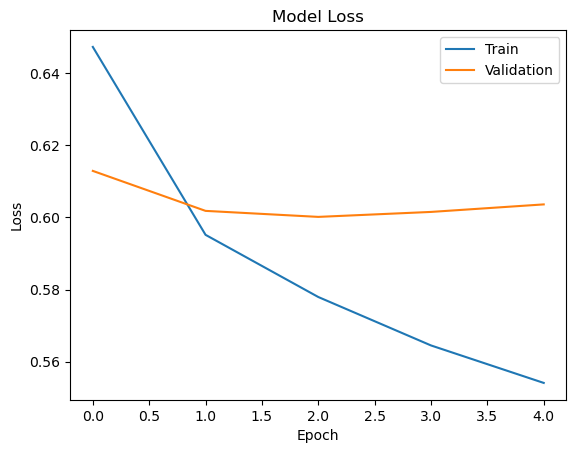

In [12]:
# ================================
# COMPILE MODEL
# ================================
model = RecommenderNet(num_users, num_movies, EMBEDDING_SIZE)
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
)

# ================================
# TRAIN MODEL
# ================================
history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=64,
    epochs=5,
    verbose=1,
    validation_data=(x_val, y_val),
)

# ================================
# PLOT TRAINING LOSS
# ================================
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

In [13]:
# ================================
# RECOMMEND MOVIES FOR A USER
# ================================
user_id = df.userId.sample(1).iloc[0]
print("Showing recommendations for user:", user_id)

user_encoder = user2user_encoded[user_id]

movies_watched = df[df.userId == user_id]
movies_not_watched = movies[
    ~movies["movieId"].isin(movies_watched.movieId.values)
]["movieId"]

movies_not_watched = list(
    set(movies_not_watched).intersection(set(movie2movie_encoded.keys()))
)

movies_not_watched_encoded = np.array(
    [[user_encoder, movie2movie_encoded[x]] for x in movies_not_watched]
)

ratings = model.predict(movies_not_watched_encoded).flatten()
top_ratings_indices = ratings.argsort()[-10:][::-1]

recommended_movie_ids = [
    movie_encoded2movie[movies_not_watched_encoded[x, 1]]
    for x in top_ratings_indices
]


Showing recommendations for user: 68
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [14]:
# ================================
# DISPLAY RESULTS
# ================================
print("--------")
print("Top 10 movie recommendations")
print("--------")

recommended_movies = movies[movies["movieId"].isin(recommended_movie_ids)]

for row in recommended_movies.itertuples():
    print(row.title, ":", row.genres)

--------
Top 10 movie recommendations
--------
Singin' in the Rain (1952) : Comedy|Musical|Romance
Rebecca (1940) : Drama|Mystery|Romance|Thriller
Star Trek: First Contact (1996) : Action|Adventure|Sci-Fi|Thriller
Rio (2011) : Adventure|Animation|Children|Comedy
Taken 2 (2012) : Action|Crime|Drama|Thriller
Day of the Doctor, The (2013) : Adventure|Drama|Sci-Fi
Interstellar (2014) : Sci-Fi|IMAX
Blended (2014) : Comedy
Doctor Who: The Time of the Doctor (2013) : Adventure|Drama
Now You See Me 2 (2016) : Action|Comedy|Thriller
